# <div dir = 'rtl'>تمرین چهارم سینا ملاابراهیمی</div>

# <div dir = 'rtl'>کتابخانه های لازم </div>

In [1]:
import pandas as pd 
import numpy as np 
import matplotlib.pylab as plt 
import seaborn as sns
from sklearn.model_selection import train_test_split
import re
from collections import Counter
import torch
from torch.utils.data import Dataset, DataLoader, TensorDataset
import torch.nn as nn
import torch.optim as optim
from sklearn.metrics import classification_report,confusion_matrix, accuracy_score

In [2]:
sns.set_style('whitegrid')

# <div dir = 'rtl'>آماده سازی و پیش پردازش</div>

In [3]:
df_train = pd.read_csv('train.csv')
df_test = pd.read_csv('test.csv')
df_train

,Class Index,Title,Description
0,1,US marines in tense Najaf standoff,"NAJAF, Iraq (Reuters) - US marines and a radic..."
1,3,Africans Need Jobs Says Former World Bank Offi...,In a commentary published in Africa Internatio...
2,4,"Nike, a magic camera and Gran Turismo Shots a...",So yesterday SPOnG began receiving shots of a ...
3,4,Custom-System Builders: Intel Price Cuts Move ...,System builders say Intel #39;s latest price c...
4,1,"About 1,000 Dead or Missing in Philippines Floods",Nearly a thousand people are dead or missing i...
...,...,...,...
29995,4,Google Acquires Satellite Map Company,In a deal that could give a boost to local sea...
29996,1,Chiefs Lead Ravens in Fourth Quarter,BALTIMORE - Priest Holmes had his third 100-ya...
29997,1,Arsonists Set Fire to Parisian Jewish Soup Kit...,PARIS (Reuters) - Arsonists set fire to a Jew...
29998,3,"AT amp;T, Cingular get OK to merge",Northern Nevada customers of Cingular Wireless...


In [4]:
df_test

,Class Index,Title,Description
0,4,Seagate claims storage record,Seagate claims to have broken the record for t...
1,1,British Terror Suspects Make First Court Appea...,LONDON (Reuters) - British terror suspects ch...
2,3,Oracle Profit Rises on Software Demand,SAN FRANCISCO (Reuters) - Oracle Corp. on Tue...
3,2,Dunn Sets Major League Strikeouts Record (AP),AP - Cincinnati Reds slugger Adam Dunn set the...
4,3,Bridges Loom as Cash Cow That Nobody Dares to ...,"There they stand, glinting in the sun, hanging..."
...,...,...,...
1995,3,ECB Eyed Rate Hike But Left Rates Steady,The European Central Bank surprised financial ...
1996,3,SICK KIDS VS. DISNEY IN #39;PETER PAN #39; DU...,It #39;s a story that would make Peter Pan gla...
1997,2,Villeneuve back in driver #39;s seat and with ...,Canadian Jacques Villeneuve hopes to take his ...
1998,3,Now It's Official: Economy Shrunk,WASHINGTON (Reuters) - The U.S. economy slowe...


In [5]:
print(df_train.info())
print('--'*25)
print(df_test.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   Class Index  30000 non-null  int64 
 1   Title        30000 non-null  object
 2   Description  30000 non-null  object
dtypes: int64(1), object(2)
memory usage: 703.3+ KB
None
--------------------------------------------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   Class Index  2000 non-null   int64 
 1   Title        2000 non-null   object
 2   Description  2000 non-null   object
dtypes: int64(1), object(2)
memory usage: 47.0+ KB
None


In [6]:
print("Train shape:", df_train.shape)
print("Test shape:", df_test.shape)

Train shape: (30000, 3)
Test shape: (2000, 3)


In [7]:
df_train['Class Index'].value_counts().sort_values()

Class Index
1    7500
3    7500
4    7500
2    7500
Name: count, dtype: int64

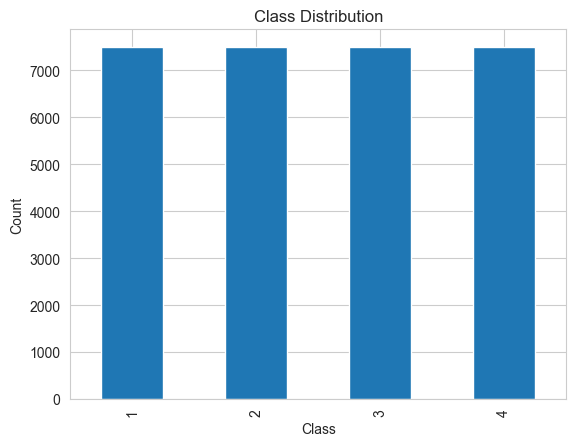

In [8]:
df_train["Class Index"].value_counts().sort_index().plot(kind="bar")
plt.title("Class Distribution")
plt.xlabel("Class")
plt.ylabel("Count")
plt.show()

In [9]:
df_train['text'] = df_train['Title'] + ' ' + df_train['Description']
df_test['text'] = df_test['Title'] + ' ' + df_test['Description']

In [10]:
train_df, val_df = train_test_split(df_train, test_size=0.2, random_state=42, stratify= df_train['Class Index'])

In [11]:
print(train_df.shape)
print(val_df.shape)
print(df_test.shape)

(24000, 4)
(6000, 4)
(2000, 4)


In [12]:
def clean_text(text):
    text = text.lower()
    text = re.sub(r"\n"," ",text)
    text = re.sub(r"[^a-z0-9\s]"," ",text)
    text = re.sub(r"\s+", " ", text)
    return text.strip()

In [13]:
train_df['text'] = train_df['text'].apply(clean_text)
val_df['text'] = val_df['text'].apply(clean_text)
df_test['text'] = df_test['text'].apply(clean_text)

In [14]:
def tokenize(text):
    return text.split()

In [15]:
print(tokenize(train_df["text"].iloc[0])[:20])

['cassini', 'spies', 'two', 'moons', 'around', 'saturn', 'ap', 'ap', 'nasa', 's', 'cassini', 'spacecraft', 'has', 'spied', 'two', 'new', 'little', 'moons', 'around', 'satellite']


In [16]:
counter = Counter()
for text in train_df['text']:
    counter.update(tokenize(text))

In [17]:
vocab ={"<PAD>":0, "<UNK>":1}
for word, freq in counter.items():
    vocab[word] = len(vocab)

In [18]:
print("Vocabulary Size:", len(vocab))

Vocabulary Size: 35559


In [19]:
def encode(text, vocab):
    return[vocab.get(word,vocab["<UNK>"])for word in tokenize(text)]

In [20]:
train_df['encoded'] = train_df['text'].apply(lambda x : encode(x, vocab))
val_df['encoded'] = val_df['text'].apply(lambda x: encode(x, vocab))
df_test['encoded'] = df_test['text'].apply(lambda x: encode(x, vocab))

In [21]:
def pad_sequence(seq,max_len):
    if len(seq)> max_len:
        return seq[:max_len]
    return seq + [vocab["<PAD>"]] * (max_len - len(seq))

In [22]:
MAX_LEN = 100
train_df["padded"] = train_df["encoded"].apply(lambda x: pad_sequence(x, MAX_LEN))
val_df["padded"] = val_df["encoded"].apply(lambda x: pad_sequence(x, MAX_LEN))
df_test["padded"] = df_test["encoded"].apply(lambda x: pad_sequence(x, MAX_LEN))

In [23]:
class NewsDataset(Dataset):
    
    def __init__(self, texts, labels):
        self.texts = torch.tensor(texts, dtype=torch.long)
        self.labels = torch.tensor(labels, dtype=torch.long)
    
    def __len__(self):
        return len(self.labels)
    
    def __getitem__(self, idx):
        return self.texts[idx], self.labels[idx]

In [24]:
train_dataset = NewsDataset(train_df["padded"].tolist(),(train_df["Class Index"].values - 1).tolist())

val_dataset = NewsDataset(val_df["padded"].tolist(),(val_df["Class Index"].values - 1).tolist())

test_dataset = NewsDataset(df_test["padded"].tolist(),(df_test["Class Index"].values - 1).tolist())

In [25]:
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

# <div dir = 'rtl'>طراحی و پیاده سازی مدل</div>

In [26]:
class GRUModel(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_size, num_layers=2, num_classes=2 , dropout = 0.3):
        super(GRUModel, self).__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.gru = nn.GRU(embed_dim, hidden_size,num_layers=num_layers, dropout=dropout, batch_first=True)
        self.dropout =nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_size, num_classes)
    def forward(self, x):
        x = self.embedding(x)
        out, hidden = self.gru(x)
        out = self.dropout(hidden[-1])
        out = self.fc(out)
        return out

In [27]:
device = 'cuda'
model = GRUModel(
    vocab_size=len(vocab),
    embed_dim=128,
    hidden_size=128,
    num_layers=2,
    dropout=0.3,
    num_classes=4
).to(device)

In [28]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [29]:
total_params = sum(p.numel() for p in model.parameters()if p.requires_grad)
print("Trainable Parameters:", total_params)

Trainable Parameters: 4750212


# <div dir = 'rtl'>آموزش مدل </div>

In [30]:
def train_one_epoch(model, dataloader, criterion, optimizer, device):
    model.train()
    total_loss = 0
    correct = 0 
    total = 0 
    for inputs, labels in dataloader:
        inputs = inputs.to(device)
        labels = labels.to(device)
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1)
        optimizer.step()
        total_loss += loss.item()
        preds = outputs.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)
    avg_loss = total_loss / len(dataloader)
    accuracy = correct / total

    return avg_loss, accuracy

In [31]:
def evaluate(model, dataloader, criterion, device):
    model.eval()
    total_loss = 0
    correct = 0
    total = 0
    with torch.no_grad():
        for inputs, labels in dataloader:
            inputs = inputs.to(device)
            labels = labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            total_loss += loss.item()
            preds = outputs.argmax(dim=1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)
    avg_loss = total_loss / len(dataloader)
    accuracy = correct / total
    return avg_loss, accuracy

In [32]:
def fit(model,train_loader,val_loader,criterion,optimizer,device, 
        epochs=20,patience=3):
    history = {"train_loss": [],"train_acc": [],"val_loss": [],
        "val_acc": []}

    best_val_loss = float("inf")
    counter = 0
    for epoch in range(epochs):
        train_loss, train_acc = train_one_epoch(model,train_loader, criterion,
            optimizer,device)

        val_loss, val_acc = evaluate(model,val_loader,criterion,device)

        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)
        print(
            f"Epoch [{epoch+1}/{epochs}] | "
            f"Train Loss: {train_loss:.4f} | "
            f"Train Acc: {train_acc:.4f} | "
            f"Val Loss: {val_loss:.4f} | "
            f"Val Acc: {val_acc:.4f}"
        )

        if val_loss < best_val_loss:

            best_val_loss = val_loss
            torch.save( model.state_dict(), "best_model.pt" )
            counter = 0
        else:
            counter += 1
            if counter >= patience:
                print("Early Stopping Triggered")
                break

    return history

In [33]:
model = GRUModel(
    vocab_size=len(vocab),
    embed_dim=128,
    hidden_size=128,
    num_layers=2,
    dropout=0.3,
    num_classes=4
).to(device)

criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001
)

history = fit(
    model,
    train_loader,
    val_loader,
    criterion,
    optimizer,
    device,
    epochs=20,
    patience=3
)

Epoch [1/20] | Train Loss: 1.3869 | Train Acc: 0.2490 | Val Loss: 1.3874 | Val Acc: 0.2500
Epoch [2/20] | Train Loss: 1.3794 | Train Acc: 0.2570 | Val Loss: 1.3724 | Val Acc: 0.2628
Epoch [3/20] | Train Loss: 1.2716 | Train Acc: 0.3406 | Val Loss: 0.9120 | Val Acc: 0.6003
Epoch [4/20] | Train Loss: 0.5423 | Train Acc: 0.7967 | Val Loss: 0.4222 | Val Acc: 0.8545
Epoch [5/20] | Train Loss: 0.2762 | Train Acc: 0.9118 | Val Loss: 0.3991 | Val Acc: 0.8657
Epoch [6/20] | Train Loss: 0.1664 | Train Acc: 0.9511 | Val Loss: 0.4559 | Val Acc: 0.8600
Epoch [7/20] | Train Loss: 0.1056 | Train Acc: 0.9709 | Val Loss: 0.4895 | Val Acc: 0.8713
Epoch [8/20] | Train Loss: 0.0663 | Train Acc: 0.9822 | Val Loss: 0.5637 | Val Acc: 0.8713
Early Stopping Triggered


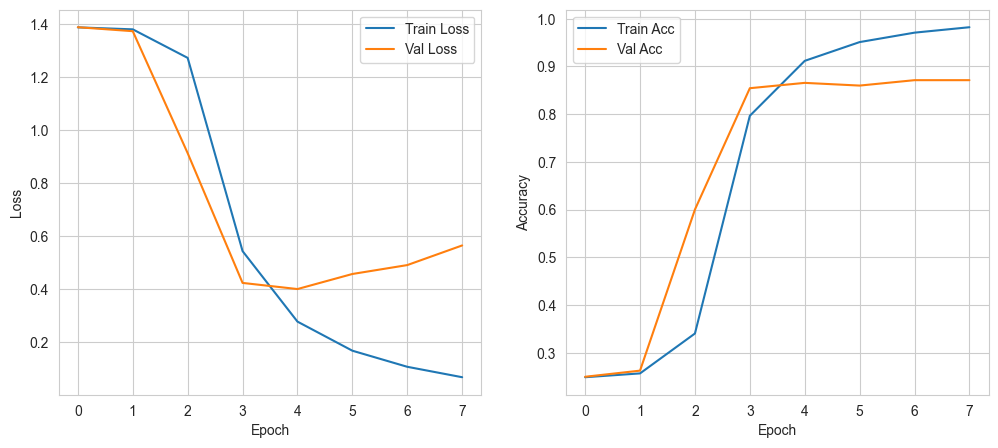

In [34]:
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.plot(history["train_loss"], label="Train Loss")
plt.plot(history["val_loss"], label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.subplot(1,2,2)
plt.plot(history["train_acc"], label="Train Acc")
plt.plot(history["val_acc"], label="Val Acc")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

# <div dir = 'rtl'>تنظیم هایپر پارامتر ها </div>

In [35]:
hidden_sizes = [64, 128, 256]
hidden_results = []
for hidden_size in hidden_sizes:
    print(f"\nTraining Hidden Size = {hidden_size}")
    model = GRUModel( vocab_size=len(vocab),embed_dim=128,hidden_size=hidden_size,num_layers=2,dropout=0.3,num_classes=4).to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam( model.parameters(),lr=0.001)
    history = fit( model,train_loader,val_loader,criterion,optimizer,device,epochs=20,patience=3)
    best_val_acc = max(history["val_acc"])
    hidden_results.append([hidden_size, best_val_acc])


Training Hidden Size = 64
Epoch [1/20] | Train Loss: 1.3865 | Train Acc: 0.2504 | Val Loss: 1.3870 | Val Acc: 0.2500
Epoch [2/20] | Train Loss: 1.3841 | Train Acc: 0.2504 | Val Loss: 1.3855 | Val Acc: 0.2502
Epoch [3/20] | Train Loss: 1.2240 | Train Acc: 0.3777 | Val Loss: 0.9136 | Val Acc: 0.5753
Epoch [4/20] | Train Loss: 0.6931 | Train Acc: 0.7163 | Val Loss: 0.5278 | Val Acc: 0.8157
Epoch [5/20] | Train Loss: 0.3732 | Train Acc: 0.8844 | Val Loss: 0.4204 | Val Acc: 0.8620
Epoch [6/20] | Train Loss: 0.2563 | Train Acc: 0.9248 | Val Loss: 0.4079 | Val Acc: 0.8685
Epoch [7/20] | Train Loss: 0.1824 | Train Acc: 0.9510 | Val Loss: 0.4474 | Val Acc: 0.8750
Epoch [8/20] | Train Loss: 0.1379 | Train Acc: 0.9649 | Val Loss: 0.4753 | Val Acc: 0.8753
Epoch [9/20] | Train Loss: 0.1076 | Train Acc: 0.9737 | Val Loss: 0.5167 | Val Acc: 0.8752
Early Stopping Triggered

Training Hidden Size = 128
Epoch [1/20] | Train Loss: 1.3868 | Train Acc: 0.2519 | Val Loss: 1.3870 | Val Acc: 0.2508
Epoch [2/2

In [36]:
hidden_df = pd.DataFrame(hidden_results,columns=["Hidden Size", "Val Accuracy"])
hidden_df

,Hidden Size,Val Accuracy
0,64,0.875333
1,128,0.874167
2,256,0.869167


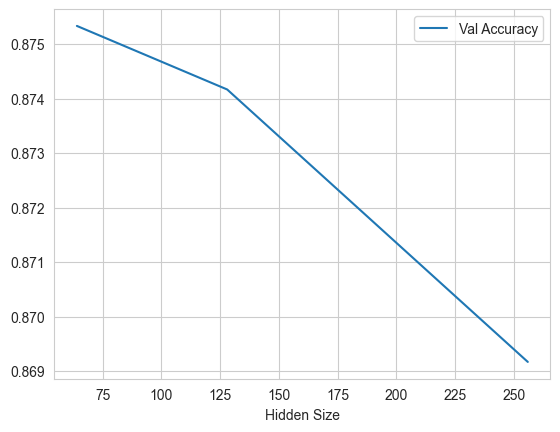

In [75]:
hidden_df.plot(x="Hidden Size",y="Val Accuracy")
plt.show()

In [38]:
def create_padded_data(max_len):
    train_pad = train_df["encoded"].apply(lambda x: pad_sequence(x, max_len))
    val_pad = val_df["encoded"].apply(lambda x: pad_sequence(x, max_len))
    train_dataset = NewsDataset(train_pad.tolist(),(train_df["Class Index"].values - 1).tolist())
    val_dataset = NewsDataset( val_pad.tolist(), (val_df["Class Index"].values - 1).tolist())
    train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
    val_loader = DataLoader( val_dataset,batch_size=32,shuffle=False)
    return train_loader, val_loader

In [39]:
seq_lengths = [50, 100, 150]
seq_results = []
for seq_len in seq_lengths:
    print(f"\nTraining Max Length = {seq_len}")
    train_loader_hp, val_loader_hp = create_padded_data(seq_len)
    model = GRUModel( vocab_size=len(vocab),embed_dim=128,hidden_size=128,num_layers=2,dropout=0.3,num_classes=4).to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(),lr=0.001)
    history = fit(model,train_loader_hp,val_loader_hp,criterion,optimizer,device,epochs=20,patience=5)
    best_val_acc = max(history["val_acc"])
    seq_results.append([seq_len, best_val_acc])


Training Max Length = 50
Epoch [1/20] | Train Loss: 0.8828 | Train Acc: 0.6087 | Val Loss: 0.5057 | Val Acc: 0.8238
Epoch [2/20] | Train Loss: 0.3937 | Train Acc: 0.8680 | Val Loss: 0.3868 | Val Acc: 0.8688
Epoch [3/20] | Train Loss: 0.2524 | Train Acc: 0.9175 | Val Loss: 0.3749 | Val Acc: 0.8765
Epoch [4/20] | Train Loss: 0.1636 | Train Acc: 0.9501 | Val Loss: 0.4366 | Val Acc: 0.8718
Epoch [5/20] | Train Loss: 0.1048 | Train Acc: 0.9680 | Val Loss: 0.4815 | Val Acc: 0.8772
Epoch [6/20] | Train Loss: 0.0634 | Train Acc: 0.9819 | Val Loss: 0.5408 | Val Acc: 0.8750
Epoch [7/20] | Train Loss: 0.0384 | Train Acc: 0.9890 | Val Loss: 0.6362 | Val Acc: 0.8705
Epoch [8/20] | Train Loss: 0.0321 | Train Acc: 0.9912 | Val Loss: 0.6857 | Val Acc: 0.8715
Early Stopping Triggered

Training Max Length = 100
Epoch [1/20] | Train Loss: 1.3869 | Train Acc: 0.2535 | Val Loss: 1.3874 | Val Acc: 0.2500
Epoch [2/20] | Train Loss: 1.3767 | Train Acc: 0.2568 | Val Loss: 1.3723 | Val Acc: 0.2528
Epoch [3/20]

In [40]:
seq_df = pd.DataFrame(seq_results,columns=["Max Length","Val Accuracy"])
seq_df

,Max Length,Val Accuracy
0,50,0.877167
1,100,0.874333
2,150,0.869333


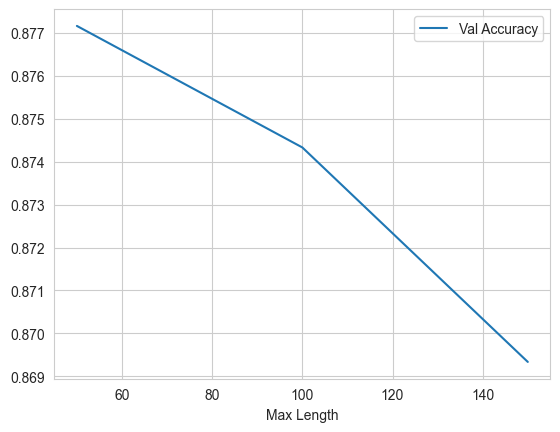

In [74]:
seq_df.plot(x='Max Length',y='Val Accuracy');

# <div dir = 'rtl'>ارزیابی نهایی مدل </div>

In [42]:
MAX_LEN = 50
train_df["padded"] = train_df["encoded"].apply(lambda x: pad_sequence(x, MAX_LEN))
val_df["padded"] = val_df["encoded"].apply(lambda x: pad_sequence(x, MAX_LEN))
df_test["padded"] = df_test["encoded"].apply(lambda x: pad_sequence(x, MAX_LEN))
train_dataset = NewsDataset(train_df["padded"].tolist(),(train_df["Class Index"].values - 1).tolist())
val_dataset = NewsDataset(val_df["padded"].tolist(),(val_df["Class Index"].values - 1).tolist())
test_dataset = NewsDataset(df_test["padded"].tolist(),(df_test["Class Index"].values - 1).tolist())
train_loader = DataLoader(train_dataset,batch_size=32,shuffle=True)
val_loader = DataLoader(val_dataset,batch_size=32,shuffle=False)
test_loader = DataLoader(test_dataset,batch_size=32,shuffle=False)

In [61]:
model = GRUModel(
    vocab_size=len(vocab),
    embed_dim=128,
    hidden_size=64,
    num_layers=2,
    dropout=0.3,
    num_classes=4
).to(device)

In [62]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(),lr=0.001)
history = fit(
    model,
    train_loader,
    val_loader,
    criterion,
    optimizer,
    device,
    epochs=20,
    patience=5
)

Epoch [1/20] | Train Loss: 0.9416 | Train Acc: 0.5613 | Val Loss: 0.5647 | Val Acc: 0.7880
Epoch [2/20] | Train Loss: 0.4305 | Train Acc: 0.8523 | Val Loss: 0.4264 | Val Acc: 0.8503
Epoch [3/20] | Train Loss: 0.2876 | Train Acc: 0.9079 | Val Loss: 0.4043 | Val Acc: 0.8645
Epoch [4/20] | Train Loss: 0.2013 | Train Acc: 0.9386 | Val Loss: 0.4230 | Val Acc: 0.8680
Epoch [5/20] | Train Loss: 0.1372 | Train Acc: 0.9607 | Val Loss: 0.5431 | Val Acc: 0.8538
Epoch [6/20] | Train Loss: 0.0993 | Train Acc: 0.9717 | Val Loss: 0.5267 | Val Acc: 0.8700
Epoch [7/20] | Train Loss: 0.0674 | Train Acc: 0.9810 | Val Loss: 0.5865 | Val Acc: 0.8623
Epoch [8/20] | Train Loss: 0.0485 | Train Acc: 0.9873 | Val Loss: 0.6573 | Val Acc: 0.8622
Early Stopping Triggered


In [63]:
model.load_state_dict(torch.load("best_model.pt"))

<All keys matched successfully>

In [64]:
model.eval()
all_preds = []
all_labels = []

with torch.no_grad():

    for inputs, labels in test_loader:

        inputs = inputs.to(device)

        outputs = model(inputs)

        preds = outputs.argmax(dim=1)

        all_preds.extend(
            preds.cpu().numpy()
        )

        all_labels.extend(
            labels.numpy()
        )

acc = accuracy_score(
    all_labels,
    all_preds
)

print("Test Accuracy:", acc)

Test Accuracy: 0.8655


In [65]:
print(classification_report(all_labels,all_preds,target_names=["World","Sports","Business","Sci/Tech"]))

              precision    recall  f1-score   support

       World       0.84      0.89      0.86       500
      Sports       0.95      0.92      0.93       500
    Business       0.84      0.82      0.83       500
    Sci/Tech       0.84      0.83      0.84       500

    accuracy                           0.87      2000
   macro avg       0.87      0.87      0.87      2000
weighted avg       0.87      0.87      0.87      2000



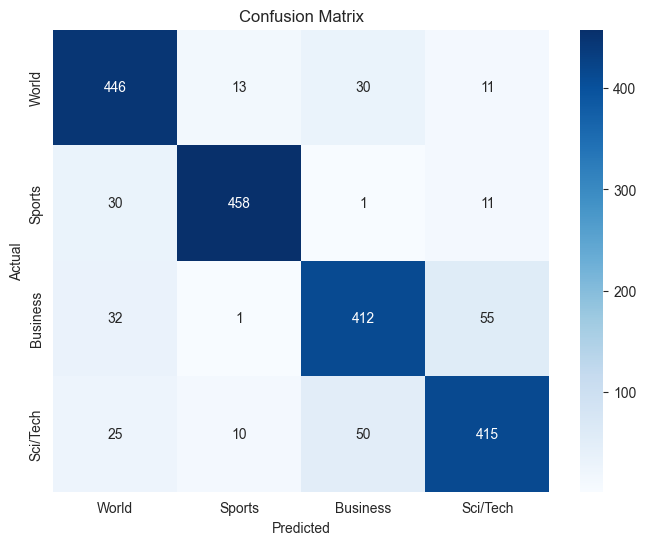

In [66]:
cm = confusion_matrix( all_labels, all_preds)
plt.figure(figsize=(8,6))
sns.heatmap(cm,annot=True,fmt="d",cmap="Blues",xticklabels=["World","Sports","Business","Sci/Tech"],
    yticklabels=[
        "World",
        "Sports",
        "Business",
        "Sci/Tech"
    ])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

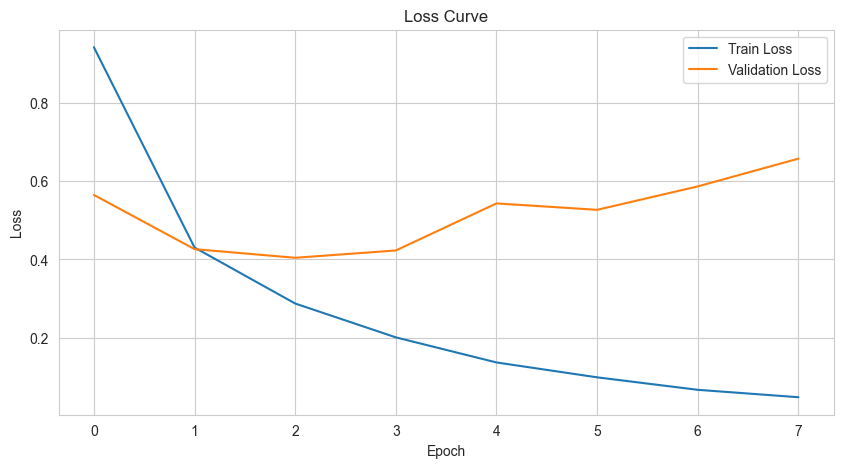

In [67]:
plt.figure(figsize=(10,5))
plt.plot(history["train_loss"],label="Train Loss")
plt.plot( history["val_loss"],label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss Curve")
plt.legend()
plt.show()

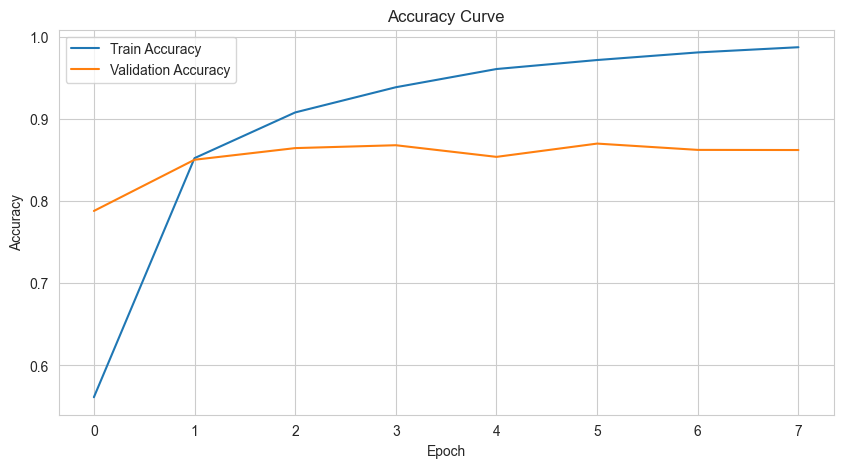

In [68]:
plt.figure(figsize=(10,5))

plt.plot( history["train_acc"],label="Train Accuracy")

plt.plot(history["val_acc"],label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Accuracy Curve")
plt.legend()
plt.show()

In [69]:
correct_samples = []
model.eval()
with torch.no_grad():
    for idx in range(len(df_test)):
        text = df_test.iloc[idx]["text"]
        label = df_test.iloc[idx]["Class Index"] - 1
        x = torch.tensor([df_test.iloc[idx]["padded"]],dtype=torch.long).to(device)
        pred = model(x).argmax(1).item()
        if pred == label:
            correct_samples.append((text, label, pred))
for i in range(5):
    print("="*100)
    print("TEXT:")
    print(correct_samples[i][0][:500])
    print("\nTRUE CLASS:")
    print(correct_samples[i][1])
    print("\nPREDICTED CLASS:")
    print(correct_samples[i][2])

TEXT:
seagate claims storage record seagate claims to have broken the record for the most storage on a single disc platter managing to store 133gb per disc in its newly released 400gb hard drive

TRUE CLASS:
3

PREDICTED CLASS:
3
TEXT:
british terror suspects make first court appearance london reuters british terror suspects charged in a plot linked to security alerts at financial targets in new york new jersey and washington made their first court appearance wednesday inside a high security prison

TRUE CLASS:
0

PREDICTED CLASS:
0
TEXT:
oracle profit rises on software demand san francisco reuters oracle corp on tuesday reported a higher quarterly profit as the world s second largest software company benefited from steady demand for its flagship database software

TRUE CLASS:
2

PREDICTED CLASS:
2
TEXT:
dunn sets major league strikeouts record ap ap cincinnati reds slugger adam dunn set the major league record for strikeouts in one season with 190 when he fanned in his first two at ba

In [70]:
wrong_samples = []
model.eval()
with torch.no_grad():
    for idx in range(len(df_test)):
        text = df_test.iloc[idx]["text"]
        label = df_test.iloc[idx]["Class Index"] - 1
        x = torch.tensor([df_test.iloc[idx]["padded"]],dtype=torch.long).to(device)
        pred = model(x).argmax(1).item()
        if pred != label:
            wrong_samples.append((text, label, pred))
for i in range(5):
    print("="*100)
    print("TEXT:")
    print(wrong_samples[i][0][:500])
    print("\nTRUE CLASS:")
    print(wrong_samples[i][1])
    print("\nPREDICTED CLASS:")
    print(wrong_samples[i][2])

TEXT:
bridges loom as cash cow that nobody dares to milk there they stand glinting in the sun hanging off the shore of manhattan like fruit laden branches of a money tree the free bridges over the east river to brooklyn and queens

TRUE CLASS:
2

PREDICTED CLASS:
3
TEXT:
japan s comics retool the art animation in america once meant mickey mouse and winnie the pooh these days it s just as likely to mean japanese fighting cyborgs doe eyed schoolgirls and sinister monsters thanks in large part to people like john ledford

TRUE CLASS:
2

PREDICTED CLASS:
3
TEXT:
japan won t have u s beef anytime soon reuters reuters japan s lucrative market for u s beef ruptured by mad cow disease worries is likely to remain closed for the rest of this year u s meat industry officials said on thursday

TRUE CLASS:
0

PREDICTED CLASS:
3
TEXT:
cellphone industry hits snag as it woos untapped market the mobile phone industry is turning its attention to the last untapped demographic people over 65

TRUE CLASS:

# <div dir = 'rtl'>بخش اختیاری </div>

In [53]:
class BiGRUModel(nn.Module):
    def __init__(self,vocab_size,embed_dim,hidden_size,num_layers=2,num_classes=4,dropout=0.3):
        super(BiGRUModel, self).__init__()
        self.embedding = nn.Embedding(vocab_size,embed_dim,padding_idx=0)
        self.gru = nn.GRU(
            input_size=embed_dim,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            bidirectional=True,
            dropout=dropout)
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_size * 2,num_classes)

    def forward(self, x):
        x = self.embedding(x)
        out, hidden = self.gru(x)
        forward_hidden = hidden[-2]
        backward_hidden = hidden[-1]
        hidden_cat = torch.cat((forward_hidden, backward_hidden),dim=1)
        hidden_cat = self.dropout( hidden_cat)
        out = self.fc( hidden_cat)
        return out

In [54]:
model_bi = BiGRUModel(vocab_size=len(vocab),embed_dim=128,hidden_size=128, num_layers=2,dropout=0.3,num_classes=4).to(device)
total_params_bi = sum(p.numel()for p in model_bi.parameters()if p.requires_grad)
print("BiGRU Parameters:",total_params_bi)

BiGRU Parameters: 5047172


In [55]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model_bi.parameters(),lr=0.001)
history_bi = fit(
    model_bi,
    train_loader,
    val_loader,
    criterion,
    optimizer,
    device,
    epochs=20,
    patience=5
)

Epoch [1/20] | Train Loss: 0.6999 | Train Acc: 0.7258 | Val Loss: 0.4733 | Val Acc: 0.8362
Epoch [2/20] | Train Loss: 0.3294 | Train Acc: 0.8888 | Val Loss: 0.4063 | Val Acc: 0.8647
Epoch [3/20] | Train Loss: 0.2073 | Train Acc: 0.9310 | Val Loss: 0.3983 | Val Acc: 0.8728
Epoch [4/20] | Train Loss: 0.1168 | Train Acc: 0.9620 | Val Loss: 0.4745 | Val Acc: 0.8697
Epoch [5/20] | Train Loss: 0.0639 | Train Acc: 0.9798 | Val Loss: 0.6095 | Val Acc: 0.8723
Epoch [6/20] | Train Loss: 0.0351 | Train Acc: 0.9890 | Val Loss: 0.6855 | Val Acc: 0.8720
Epoch [7/20] | Train Loss: 0.0258 | Train Acc: 0.9924 | Val Loss: 0.8380 | Val Acc: 0.8610
Epoch [8/20] | Train Loss: 0.0195 | Train Acc: 0.9942 | Val Loss: 0.8520 | Val Acc: 0.8702
Early Stopping Triggered


In [56]:
model_bi.load_state_dict(
    torch.load("best_model.pt")
)

<All keys matched successfully>

In [57]:
model_bi.eval()
all_preds_bi = []
all_labels_bi = []
with torch.no_grad():
    for inputs, labels in test_loader:
        inputs = inputs.to(device)
        outputs = model_bi(inputs)
        preds = outputs.argmax(1)
        all_preds_bi.extend(preds.cpu().numpy())
        all_labels_bi.extend(labels.numpy())
bi_acc = accuracy_score(all_labels_bi,all_preds_bi)
print("BiGRU Test Accuracy:",bi_acc)
print(classification_report(all_labels_bi,all_preds_bi,
        target_names=[
            "World",
            "Sports",
            "Business",
            "Sci/Tech"
        ]))

BiGRU Test Accuracy: 0.8625
              precision    recall  f1-score   support

       World       0.91      0.87      0.89       500
      Sports       0.97      0.90      0.93       500
    Business       0.82      0.79      0.80       500
    Sci/Tech       0.78      0.89      0.83       500

    accuracy                           0.86      2000
   macro avg       0.87      0.86      0.86      2000
weighted avg       0.87      0.86      0.86      2000



In [71]:
gru_params = sum(p.numel()for p in model.parameters()if p.requires_grad)
bigru_params = sum(p.numel()for p in model_bi.parameters()if p.requires_grad)
comparison = pd.DataFrame({
    "Model":[
        "GRU",
        "BiGRU"
    ],
    "Parameters":[
        gru_params,
        bigru_params]})
comparison

,Model,Parameters
0,GRU,4614020
1,BiGRU,5047172


In [72]:
comparison_acc = pd.DataFrame({
    "Model":[
        "GRU",
        "BiGRU"],
    "Accuracy":[
        acc,
        bi_acc]})
comparison_acc

,Model,Accuracy
0,GRU,0.8655
1,BiGRU,0.8625


In [60]:
gru_preds = []
bigru_preds = []
model.eval()
model_bi.eval()
with torch.no_grad():
    for idx in range(len(df_test)):
        x = torch.tensor([df_test.iloc[idx]["padded"]],dtype=torch.long).to(device)
        gru_pred = model(x).argmax(1).item()
        bigru_pred = model_bi(x).argmax(1).item()
        true_label = ( df_test.iloc[idx]["Class Index"] - 1)
        if gru_pred != bigru_pred:
            print("="*100)
            print( df_test.iloc[idx]["text"][:500])
            print("True:", true_label)
            print("GRU:",gru_pred)
            print("BiGRU:",bigru_pred)

bridges loom as cash cow that nobody dares to milk there they stand glinting in the sun hanging off the shore of manhattan like fruit laden branches of a money tree the free bridges over the east river to brooklyn and queens
True: 2
GRU: 2
BiGRU: 3
japan s comics retool the art animation in america once meant mickey mouse and winnie the pooh these days it s just as likely to mean japanese fighting cyborgs doe eyed schoolgirls and sinister monsters thanks in large part to people like john ledford
True: 2
GRU: 3
BiGRU: 0
fda approves lens implant to sharpen sight washington there s a new option for people who suffer from extreme nearsightedness whose world loses its crisp edge just a few inches from their noses the first implantable lens for nearsightedness was approved monday by the food and drug administration
True: 0
GRU: 0
BiGRU: 2
india russia must join hands to develop new tech putin mr vladimir v putin president of the russian federation mr nr narayana murthy chief mentor and chai